## Project Subsmission 1 - Machine Learning Terapan

Nama = Yovela Kalista Avansa

Email = yovelakalista23@gmail.com

## Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost.sklearn import XGBRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score

## Gathering Dataset

In [2]:
laptop_df = pd.read_csv("https://raw.githubusercontent.com/yovelakalista23/laptop-price/refs/heads/main/dataset/laptop_data.csv")
laptop_df.drop(columns=["Unnamed: 0"], inplace=True)

laptop_df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


## Assessing Dataset

In [3]:
# Cek info dataset
laptop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   object 
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   object 
 10  Price             1303 non-null   float64
dtypes: float64(2), object(9)
memory usage: 112.1+ KB


In [4]:
laptop_df.describe()

,Inches,Price
count,1303.000000,1303.000000
mean,15.017191,59870.042910
std,1.426304,37243.201786
min,10.100000,9270.720000
25%,14.000000,31914.720000
50%,15.600000,52054.560000
75%,15.600000,79274.246400
max,18.400000,324954.720000


In [5]:
laptop_df.isna().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [6]:
print("Number of Duplicates: ", laptop_df.duplicated().sum())

Number of Duplicates:  29


In [7]:
laptop_df.drop_duplicates(inplace=True)
print("Number of Duplicates: ", laptop_df.duplicated().sum())


Number of Duplicates:  0


In [8]:
laptop_df.shape

(1274, 11)

Setelah melakukan assessing dataset, terlihat bahwa dataset bersih

## EDA (Exploratory Data Analysis)

Multivariate Analysis

Melihat hubungan antara komponen Company, Tipe Laptop, Harga, dan Berat

In [9]:
laptop_df_pivot = laptop_df.pivot_table(index = "Company", columns = "TypeName", values = "Price", margins = True).fillna(0)
laptop_df_pivot

TypeName,2 in 1 Convertible,Gaming,Netbook,Notebook,Ultrabook,Workstation,All
Company,,,,,,,
Acer,37229.466600,78221.700000,16303.680000,29130.769895,47445.840000,0.000000,33750.986186
Apple,0.000000,0.000000,0.000000,0.000000,83340.499886,0.000000,83340.499886
Asus,52021.813292,91641.886133,14183.136000,33917.205832,72066.528000,0.000000,60143.988302
Chuwi,0.000000,0.000000,0.000000,16745.726400,0.000000,0.000000,16745.726400
Dell,60295.395360,102211.979040,27678.960000,47054.265509,78743.349257,118237.329164,63894.714408
Fujitsu,0.000000,0.000000,0.000000,38841.120000,0.000000,0.000000,38841.120000
Google,0.000000,0.000000,0.000000,0.000000,89386.080000,0.000000,89386.080000
HP,80282.836800,75875.160000,65777.965714,43698.873680,81898.848800,122527.064571,57559.165307
Huawei,0.000000,0.000000,0.000000,0.000000,75870.720000,0.000000,75870.720000


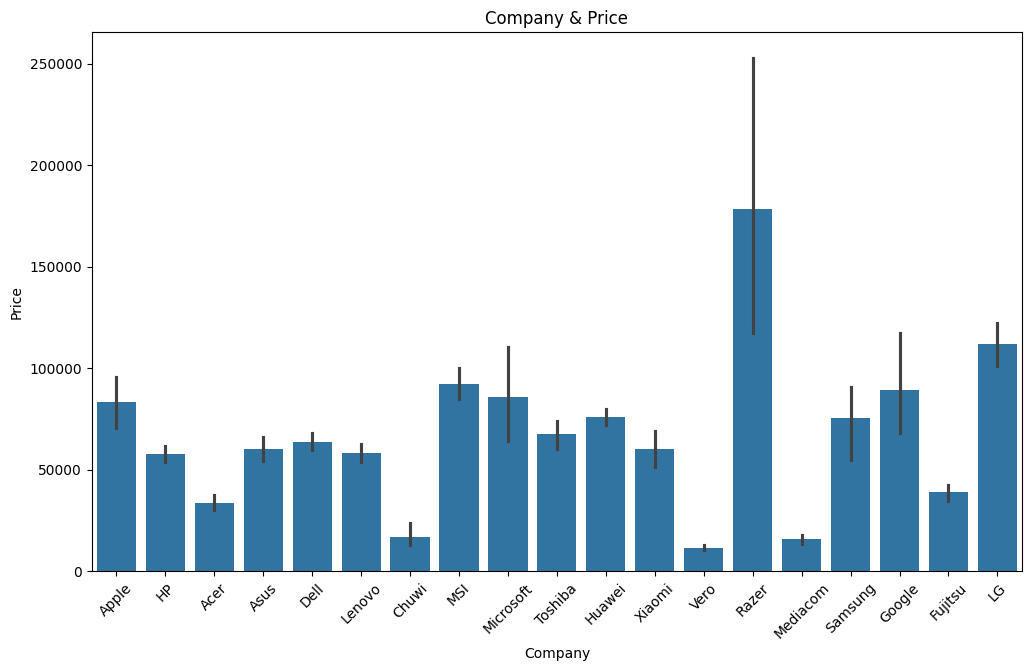

In [10]:
plt.figure(figsize = (12, 7))
sns.barplot(x = "Company", y = "Price", data = laptop_df)
plt.title("Company & Price")
plt.xticks(rotation = 45)
plt.show()
plt.show()

## Penjelasan Bar Chart dari komponen Company & Price

- **Razer** memiliki harga rata-rata tertinggi dengan variasi harga yang besar, menunjukkan adanya produk dalam berbagai kategori harga.  
- **Apple, LG, MSI, dan Google** cenderung memiliki harga rata-rata tinggi dibandingkan merek lain.  
- **HP, Lenro, dan MediaCom** memiliki harga rata-rata terendah, menunjukkan kemungkinan fokus pada pasar low-end.  
- Rentang erroovo, Dell, dan Asus** berada dalam kategori harga menengah.  
- **Chuwi, Ver bars yang besar pada beberapa merek (seperti Razer dan Microsoft) mengindikasikan variasi harga yang signifikan dalam produk mereka.  


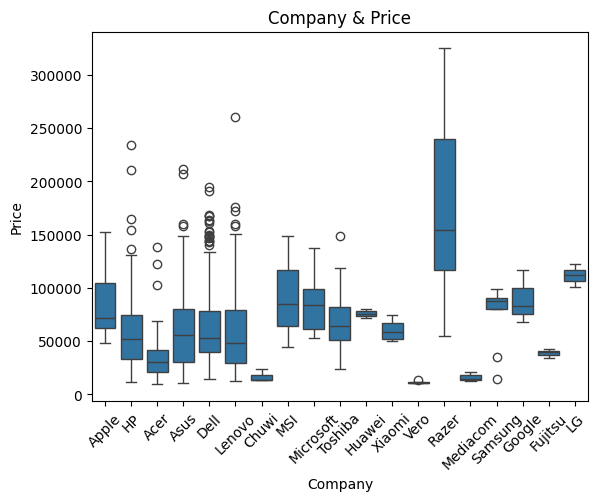

In [11]:
sns.boxplot(x = "Company", y = "Price", data = laptop_df)
plt.xticks(rotation = 45)
plt.title("Company & Price")
plt.show()

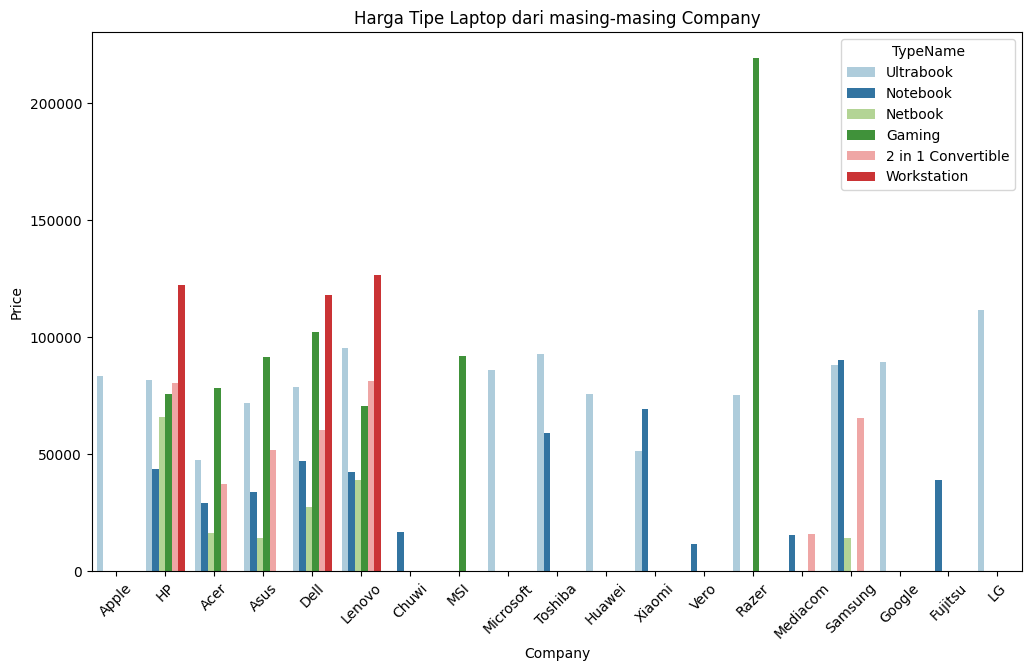

In [12]:
plt.figure(figsize = (12, 7))
sns.barplot(x = "Company", y = "Price", data = laptop_df, errorbar=None, hue = "TypeName", palette = "Paired")
plt.xticks(rotation = 45)
plt.title("Harga Tipe Laptop dari masing-masing Company")
plt.show()

## Analisis Harga Tipe Laptop Berdasarkan Komponen Company

- **Perbedaan harga antar tipe laptop cukup signifikan**, terutama untuk tipe **Gaming** dan **Workstation**, yang umumnya memiliki harga lebih tinggi dibanding tipe lainnya.  
- **Razer memiliki harga Gaming laptop tertinggi**, sementara **Workstation dari beberapa brand seperti HP dan Lenovo juga cukup mahal**.  
- **Notebook dan Ultrabook tersebar merata di berbagai perusahaan dengan harga yang lebih terjangkau** dibandingkan Gaming atau Workstation.  
- **Beberapa perusahaan seperti Apple, Microsoft, dan Huawei lebih fokus pada segmen Ultrabook**, sementara perusahaan seperti MSI dan Asus lebih banyak memiliki laptop Gaming.  
- **Vero dan MediaCom memiliki harga laptop yang relatif lebih rendah**, kemungkinan menyasar pasar entry-level.  

In [13]:
print(laptop_df["Weight"].values)
laptop_df["Weight"] = laptop_df["Weight"].str.replace("kg", "")
laptop_df["Weight"] = laptop_df["Weight"].astype(float)

['1.37kg' '1.34kg' '1.86kg' ... '1.3kg' '1.5kg' '2.19kg']


In [14]:
print(laptop_df["Ram"].values)
laptop_df["Ram"] = laptop_df["Ram"].str.replace("GB", "")
laptop_df["Ram"] = laptop_df["Ram"].astype(float)

['8GB' '8GB' '8GB' ... '16GB' '2GB' '6GB']


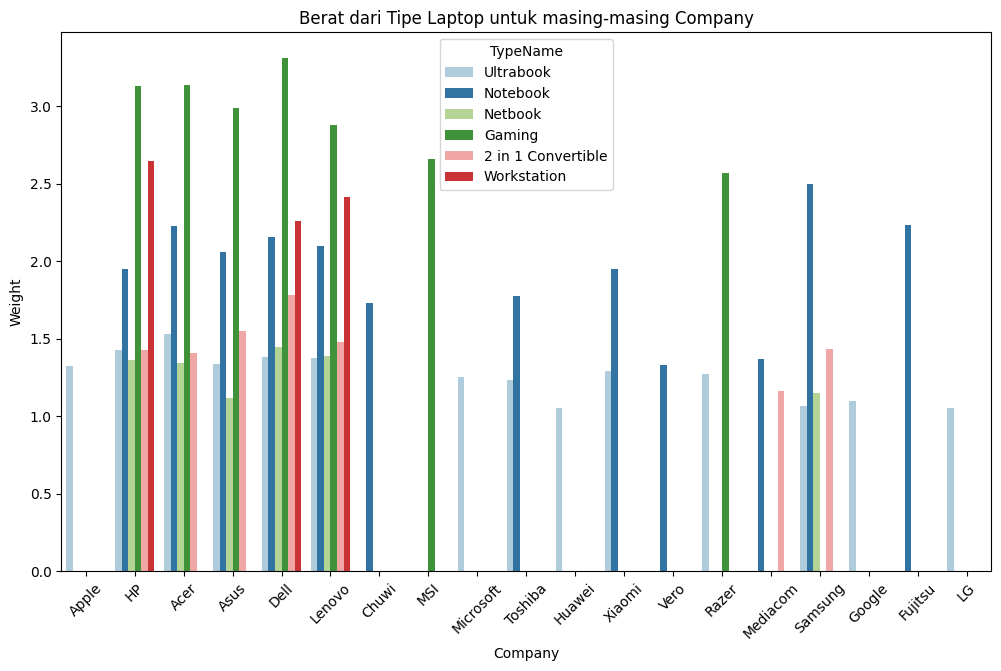

In [15]:
plt.figure(figsize = (12, 7))
sns.barplot(x = "Company", y = "Weight", data = laptop_df, errorbar = None,hue = "TypeName" , palette = "Paired")
plt.xticks(rotation = 45)
plt.title("Berat dari Tipe Laptop untuk masing-masing Company")
plt.show()

## Analisis Berat dari Tipe Laptop Berdasarkan Perusahaan

- Laptop Gaming umumnya lebih berat, terutama pada brand seperti Asus, Dell, dan Lenovo.
- Ultrabook cenderung lebih ringan dibandingkan tipe lain.
- Beberapa brand memiliki variasi laptop yang luas, seperti HP, Dell, dan Lenovo yang menawarkan berbagai tipe laptop dengan berat yang berbeda.
- Brand seperti Apple dan Microsoft memiliki laptop dengan bobot yang lebih ringan, kemungkinan karena mereka lebih fokus pada ultrabook atau perangkat tipis.

In [16]:
laptop_df.groupby("Company")["Price"].mean().sort_values(ascending = False)

Company
Razer        178282.491429
LG           111834.720000
MSI           92116.226133
Google        89386.080000
Microsoft     85903.788000
Apple         83340.499886
Huawei        75870.720000
Samsung       75308.320000
Toshiba       67549.050000
Dell          63894.714408
Xiaomi        60390.882000
Asus          60143.988302
Lenovo        58280.978790
HP            57559.165307
Fujitsu       38841.120000
Acer          33750.986186
Chuwi         16745.726400
Mediacom      15717.600000
Vero          11584.404000
Name: Price, dtype: float64

## Data Preparation

1. Menyelesaikan permasalahan duplikat data
2. Encoding features
3. Memisahkan fitur X dan Y
4. Membagi dataset dengan train_test_split dataset
5. Standarisasi

## Encoding Features

In [17]:
label_encoder = LabelEncoder()
for col in laptop_df.select_dtypes(include = ["object"]).columns:
    laptop_df[col] = label_encoder.fit_transform(laptop_df[col])

In [18]:
laptop_df.dtypes

Company               int64
TypeName              int64
Inches              float64
ScreenResolution      int64
Cpu                   int64
Ram                 float64
Memory                int64
Gpu                   int64
OpSys                 int64
Weight              float64
Price               float64
dtype: object

In [19]:
laptop_df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,1,4,13.3,23,65,8.0,4,58,8,1.37,71378.6832
1,1,4,13.3,1,63,8.0,2,51,8,1.34,47895.5232
2,7,3,15.6,8,74,8.0,16,53,4,1.86,30636.0000
3,1,4,15.4,25,85,16.0,29,9,8,1.83,135195.3360
4,1,4,13.3,23,67,8.0,16,59,8,1.37,96095.8080


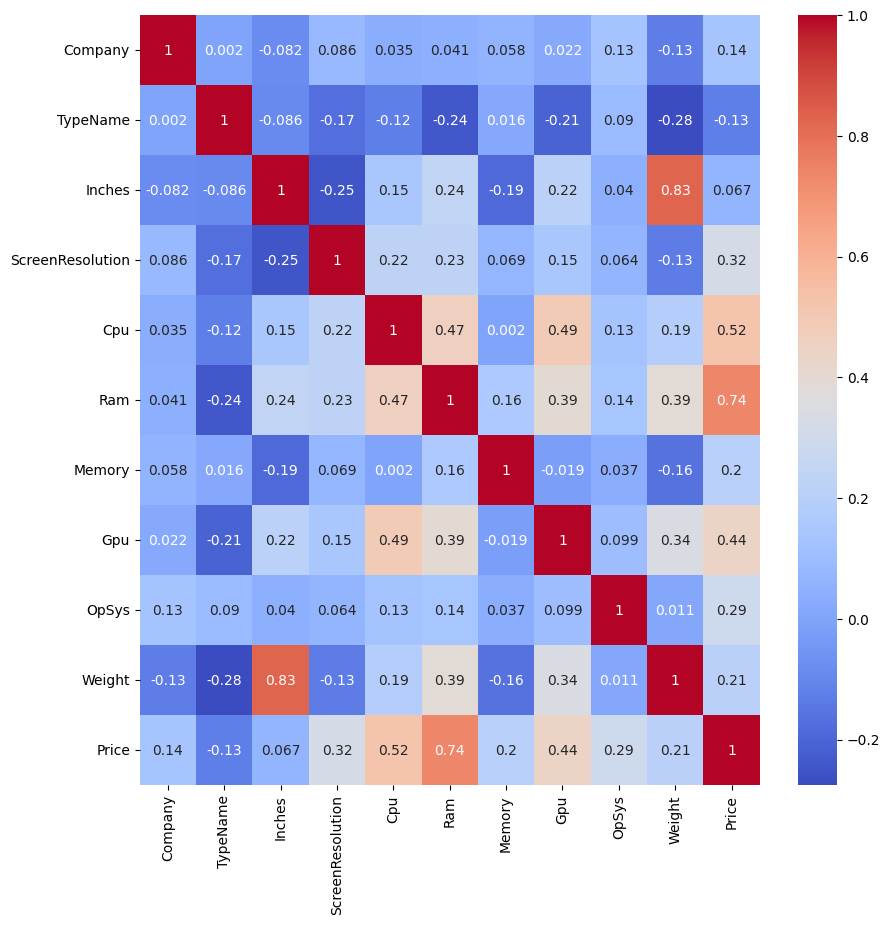

In [20]:
plt.figure(figsize = (10, 10))
sns.heatmap(laptop_df.corr(), annot = True, fmt = ".2g", cmap = "coolwarm")
plt.show()

Korelasi positif yang bisa dilihat dengan jelas yaitu antara 'Weight' dan 'Inches' kemudian antara 'Price' dan 'RAM'

## Pisahkan fitur X dan Y

Mengambil semua fitur kecuali kolom "Price" sebagai variabel independen (X).
Price adalah target yang akan diprediksi, jadi harus dikeluarkan dari fitur.

Menggunakan log transformation (np.log) untuk mengubah distribusi harga menjadi lebih normal.
Jika harga memiliki distribusi right-skewed, transformasi log dapat membantu stabilisasi varians dan meningkatkan performa model.
+1e-8 (atau 0.00000001) ditambahkan untuk menghindari error jika ada nilai 0 dalam dataset. Karena log(0) tidak terdefinisi, menambahkan nilai kecil ini mencegah error "math domain error".

In [21]:
X = laptop_df.drop("Price", axis = 1)
y = np.log(laptop_df["Price"] + 1e-8)

## Membagi dataset dengan Split Dataset

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Standarisasi

In [23]:
Scaling_Features = StandardScaler()
X_train = Scaling_Features.fit_transform(X_train)
X_test = Scaling_Features.transform(X_test)

## Build Model dengan XGBoost & Random Forest

In [24]:
# Buat model XGBoost & Random Forest
xgb_model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

In [25]:
# Train model
xgb_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)


RandomForestRegressor(max_depth=5, random_state=42)

In [26]:
# Prediksi
y_pred_xgb = xgb_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

In [27]:
# Evaluasi Model
def evaluate_model(y_test, y_pred, model_name):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"📊 Evaluasi Model: {model_name}")
    print(f"✅ Mean Squared Error (MSE): {mse:.4f}")
    print(f"✅ Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"✅ Mean Absolute Error (MAE): {mae:.4f}")
    print(f"✅ R² Score: {r2:.4f}\n")


In [28]:
# 6️⃣ Cek hasil evaluasi
evaluate_model(y_test, y_pred_xgb, "XGBoost Regressor")
evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")

📊 Evaluasi Model: XGBoost Regressor
✅ Mean Squared Error (MSE): 0.0416
✅ Root Mean Squared Error (RMSE): 0.2039
✅ Mean Absolute Error (MAE): 0.1520
✅ R² Score: 0.8909

📊 Evaluasi Model: Random Forest Regressor
✅ Mean Squared Error (MSE): 0.0689
✅ Root Mean Squared Error (RMSE): 0.2625
✅ Mean Absolute Error (MAE): 0.2042
✅ R² Score: 0.8193



## Hasil Evaluasi

- MSE(Mean Squared Error)
  Mengukur rata-rata kesalahan kuadrat antara nilai asli dan prediksi dan **semakin kecil nilainya semakin baik**
- RMSE(Root Mean Squared Error)
  Mengukur seberapa besar prediksi menyimpang dari nilai sebenarnya dan **semakin kecil nilainya semakin baik**
- MAE(Mean Absolute Error)
  Mengukur rata-rata selisih absolut antara prediksi dan nilai asli dan **semakin kecil nilainya semakin baik**
- R2 Score (Koefisien Determinasi)
  Mengukur seberapa baik model menjelaskan variasi data, **nilai lebih tinggi lebih baik. Mendekati 1.0 berarti model sangat baik**

## Hyperparameter Tuning model XGB Regressor dan Random Forest

In [29]:
# Definisikan parameter yang akan dicoba
xgb_param = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300, 500],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

rf_param = {
    'max_depth': [3, 5, 7, 9],
    'n_estimators': [100, 200, 300, 500],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'bootstrap': [True, False]
}

In [30]:
# Buat model XGBoost
xgb_tuned = XGBRegressor(random_state=42)
rf_tuned = RandomForestRegressor(random_state=42)


In [31]:
# Randomized Search
xgb_search = RandomizedSearchCV(
    estimator=xgb_tuned,
    param_distributions=xgb_param,
    n_iter=20,  # Coba 20 kombinasi
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param,
    n_iter=20,
    scoring="neg_mean_squared_error",
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)


In [32]:
# Jalankan tuning
xgb_search.fit(X_train, y_train)
rf_search.fit(X_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(max_depth=5,
                                                   random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [3, 5, 7, 9],
                                        'min_samples_leaf': [1, 3, 5],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [33]:
# Print hasil terbaik
print("Best Parameters:", xgb_search.best_params_)

print("Best Parameters:", rf_search.best_params_)


Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 9, 'bootstrap': True}


In [34]:
# Gunakan model terbaik
best_xgb = xgb_search.best_estimator_
best_rf = rf_search.best_estimator_


In [35]:
# Prediksi dengan model terbaik
y_pred_best_xgb = best_xgb.predict(X_test)
y_pred_best_rf = best_rf.predict(X_test)

In [36]:
# 5️⃣ Evaluasi Model
def evaluate_model(y_test, y_pred_best, model_name):
    mse = mean_squared_error(y_test, y_pred_best)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred_best)
    r2 = r2_score(y_test, y_pred_best)
    
    print(f"📊 Evaluasi Model: {model_name}")
    print(f"✅ Mean Squared Error (MSE): {mse:.4f}")
    print(f"✅ Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"✅ Mean Absolute Error (MAE): {mae:.4f}")
    print(f"✅ R² Score: {r2:.4f}\n")


In [37]:
# 6️⃣ Cek hasil evaluasi
evaluate_model(y_test, y_pred_best_xgb, "XGBoost Tuned")
evaluate_model(y_test, y_pred_best_rf, "Random Forest Tuned")


📊 Evaluasi Model: XGBoost Tuned
✅ Mean Squared Error (MSE): 0.0342
✅ Root Mean Squared Error (RMSE): 0.1849
✅ Mean Absolute Error (MAE): 0.1387
✅ R² Score: 0.9103

📊 Evaluasi Model: Random Forest Tuned
✅ Mean Squared Error (MSE): 0.0504
✅ Root Mean Squared Error (RMSE): 0.2244
✅ Mean Absolute Error (MAE): 0.1709
✅ R² Score: 0.8679



## Hasil Evaluasi setelah melakukan Hyperparameter Tuning

**XGBoost**

Metrik	Sebelum Tuning	Sesudah Tuning	Perbedaan

MSE	   =    0.0416	   ->    0.0342	    🔽 Lebih kecil (lebih baik)

RMSE   =    0.2039	   ->    0.1849	    🔽 Lebih kecil (lebih baik)

MAE	   =    0.1520	   ->    0.1387	    🔽 Lebih kecil (lebih baik)

R² Score  = 0.8909	   ->    0.9103	    🔼 Lebih besar (lebih baik)



**Random Forest**

Metrik	Sebelum Tuning	Sesudah Tuning	Perbedaan

MSE	  =    0.0689	   ->     0.0504	    🔽 Lebih kecil (lebih baik)

RMSE  =    0.2625	   ->     0.2244	    🔽 Lebih kecil (lebih baik)

MAE	  =    0.2042	   ->     0.1709	    🔽 Lebih kecil (lebih baik)

R² Score = 0.8193	   ->     0.8679	    🔼 Lebih besar (lebih baik)



**Kesimpulan Akhir**

- XGBoost lebih baik dibandingkan Random Forest, karena memiliki MSE yang lebih kecil dan R² yang lebih tinggi.
- Setelah tuning, kedua model mengalami peningkatan performa secara signifikan.
- XGBoost lebih unggul dalam menangani data ini karena setelah tuning, R² mencapai 0.9103, menunjukkan model ini bisa menjelaskan ~91% variabilitas data.
- Jika memilih model terbaik, XGBoost Tuned adalah pilihan terbaik untuk prediksi harga laptop.